# Генетический алгоритм: оптимизация автобусной сети Кудрово → метро «Улица Дыбенко»

**Курсовая: «Моделирование маршрутов общественного транспорта … (пригороды Санкт-Петербурга)»**

## Что это и зачем
Это **ML-эксперимент над тем же каркасом, что и бейзлайн**. Бейзлайн отбирал маршруты
жадно (greedy + swap) и застревал в локальном оптимуме. Здесь тот же выбор маршрутов
делает **генетический алгоритм** (популяционный эволюционный поиск): он держит популяцию
решений и улучшает их отбором / скрещиванием / мутацией, что позволяет уходить из локальных
оптимумов, в которых застревает жадность.

**Принцип честного сравнения (дизайн Fan & Machemehl, 2006):** меняется *только метод поиска*.
Всё остальное идентично бейзлайну —
- тот же **пул кандидатов** (k-кратчайших путей + существующие маршруты),
- та же **фитнес-функция** `T_avg` (среднее по населению время до метро) со штрафами за
  провозимость и непокрытие,
- те же **гиперпараметры** модели (скорости, dwell, парк, `commuter_share`),
- те же **метрики** (T_avg, медиана, P90, minimax, обслужено %).

Так разница в результате объясняется именно сменой оптимизатора, а не данными или допущениями.

## Архитектура (поток данных)
```
Данные (.gpkg, .csv)
   ├─ kud_roads_buses_v3 ──► ГРАФ автобусной сети (networkx, направленный, oneway)
   ├─ bus_stops_v2 ────────► времена остановка→метро и остановка→остановка
   ├─ Кудрово_парадные ────► СПРОС: население подъездов
   ├─ od_matrix_topk ──────► пешие времена подъезд→(top-3 остановки)
   └─ avtobus_marshruty ───► существующие маршруты (в пул и для сравнения)
                  │
       ГЕНЕРАЦИЯ КАНДИДАТОВ (k-кратчайших + существующие)
                  │
       ГЕНЕТИЧЕСКИЙ АЛГОРИТМ  ◄── фитнес = T_avg (тот же, что в бейзлайне)
                  │
       сравнение с жадным бейзлайном и существующей сетью
```

## Воспроизводимость
Случайность ГА зафиксирована `seed` (блок параметров `GA`). При том же seed результат
повторяется бит-в-бит. Ниже также есть отдельная ячейка **мульти-seed прогона** (mean ± std)
— поскольку ГА стохастичен, в отчёте корректно приводить разброс по нескольким запускам.


## 1. Параметры модели
Блок `P` — **идентичен бейзлайну** (не меняем, чтобы сравнение было честным). Блок `GA` — гиперпараметры генетического алгоритма.

In [19]:
import json, pickle, numpy as np, pandas as pd, geopandas as gpd, networkx as nx
from shapely.geometry import LineString
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    display = print

CRS = 32636  # метрическая проекция (UTM 36N) — все расстояния в метрах

# ── ПАРАМЕТРЫ МОДЕЛИ (идентичны бейзлайну) ───────────────────────────────────
P = dict(
    walk_speed_mps   = 5*1000/3600,   # пешая скорость 5 км/ч
    bus_cruise_kmh   = 40,            # дефолтный лимит скорости, если нет maxspeed
    bus_speed_factor = 0.65,          # реальная скорость = 0.65 * лимит (трафик/светофоры)
    dwell_s          = 29,            # потеря времени на 1 остановку, с
    layover_factor   = 1.15,          # оборотное время = 2*(в пути)*коэф (отстой на конце)
    alpha_zan        = 0.568,         # доля занятого населения
    beta_vyezd       = 0.7,           # доля работающих вне района
    gamma_ot         = 0.565,         # доля пользователей ОТ среди занятых
    k_shortest       = 3,             # k-кратчайших путей от каждой остановки-семени
    n_seeds          = 44,            # сколько остановок используем как семена (44 = все)
    max_routes       = 8,             # верхняя граница числа маршрутов в сети
    unserved_penalty_s = 3600,        # штраф подъезду без обслуживаемой остановки
    peak_hours       = 2.0,           # длительность утреннего пика, ч
    min_stops        = 3,             # минимум остановок в маршруте, не считая метро
    stop_dedup_m     = 206,           # схлопывать соседние остановки маршрута ближе этого, м
)
P['commuter_share'] = P['alpha_zan']*P['beta_vyezd']*P['gamma_ot']   # ≈ 0.225

P['commuter_share'] = 0.15   # скорректированная оценка доли коммьютеров на ОТ
# (раньше = alpha*beta*gamma ≈ 0.225). Влияет на поток и overflow-штраф.
print("commuter_share:", round(P['commuter_share'], 3))

# ── ПУТИ К ФАЙЛАМ (зеркалят новый бейзлайн; поправьте под свои папки) ─────────
PATHS = dict(
    roads        = r"C:\Users\georg\NIS\Curse_work_2026\kud_roads_buses_v3.gpkg",
    stops        = r"C:\Users\georg\NIS\Curse_work_2026\bus_stops_v2.gpkg",
    ent          = r"C:/Users/georg/Downloads/paradniye_with_pop_v2.gpkg",
    od           = r"C:\Users\georg\NIS\od_matrix_topk.csv",
    existing     = r"C:\Users\georg\Documents\kud_routes.gpkg",          # слой 'existing_routes'
    podyezd_dist = r"C:\Users\georg\NIS\Curse_work_2026\podyezd_dist_to_metro.csv",
    out          = r"C:\Users\georg\NIS\Curse_work_2026\ga_routes_v2.gpkg",
)

# ── ГИПЕРПАРАМЕТРЫ ГЕНЕТИЧЕСКОГО АЛГОРИТМА ────────────────────────────────────
GA = dict(
    pop_size   = 60,    # размер популяции
    generations= 80,    # число поколений
    elite      = 4,     # сколько лучших переносим без изменений (элитизм)
    tournament = 3,     # размер турнира при отборе
    p_cross    = 0.85,  # вероятность скрещивания
    p_mut      = 0.30,  # вероятность мутации потомка
    r_min      = 2,     # мин. число маршрутов в решении
    r_max      = 8,     # макс. число маршрутов в решении (= P['max_routes'])
    seed       = 42,    # фиксируем случайность => воспроизводимость
)

# ── ПАРК (смешанный): ЛиАЗ-5292 ×8 (117 чел) + Volgabus-4298 ×10 (49 чел) ──────
def make_fleet(n_liaz, n_volga):
    return sorted([117]*n_liaz + [49]*n_volga, reverse=True)
FLEET = make_fleet(8, 10)   # фактический парк = 18 машин
print("Парк:", len(FLEET), "машин, вместимость", sum(FLEET), "чел/рейс")

commuter_share: 0.15
Парк: 18 машин, вместимость 1426 чел/рейс


## 2. Граф автобусной сети
Из слоя дорог строим **направленный** граф: двусторонние дороги → два ребра, `oneway=yes` → одно. Вес ребра = время = длина / скорость. (Код идентичен бейзлайну.)

In [20]:
def parse_maxspeed(v, default_kmh):
    if v is None or (isinstance(v, float) and np.isnan(v)): return default_kmh
    s = str(v)
    if s == 'RU:urban': return 60
    try: return float(s.split()[0])
    except: return default_kmh

def build_bus_graph(roads_gpkg, layer='doroga_for_busiki'):
    gdf = gpd.read_file(roads_gpkg, layer=layer).to_crs(CRS).explode(index_parts=False)
    G = nx.DiGraph()
    for _, row in gdf.iterrows():
        g = row.geometry
        if g is None or g.is_empty: continue
        v = parse_maxspeed(row.get('maxspeed'), P['bus_cruise_kmh']) * P['bus_speed_factor'] * 1000/3600
        oneway = (row.get('oneway') == 'yes')
        c = list(g.coords)
        for i in range(len(c)-1):
            u = (round(c[i][0],1),   round(c[i][1],1))
            w = (round(c[i+1][0],1), round(c[i+1][1],1))
            if u == w: continue
            L = LineString([c[i], c[i+1]]).length
            G.add_edge(u, w, length=L, time=L/v)
            if not oneway: G.add_edge(w, u, length=L, time=L/v)
    for n in G.nodes: G.nodes[n]['x'], G.nodes[n]['y'] = n
    return G.subgraph(max(nx.strongly_connected_components(G), key=len)).copy()

G = build_bus_graph(PATHS['roads'])
print("Граф:", G.number_of_nodes(), "узлов,", G.number_of_edges(), "рёбер")

Граф: 1385 узлов, 2709 рёбер


## 3. Спрос и пешие времена
Подъезды с населением + OD-матрица (пешие расстояния до 3 ближайших остановок). Остановки метро «Дыбенко» — **сток**, исключаем из посадочных. (Идентично бейзлайну.)

In [21]:
ent = gpd.read_file(PATHS['ent']).to_crs(CRS).reset_index(drop=True)
ent['entrance_id'] = ent.index + 1
ent_pop = ent.set_index('entrance_id')['population']

stops = gpd.read_file(PATHS['stops']).to_crs(CRS).reset_index(drop=True)
is_metro = stops['name'].astype(str).str.contains('Дыбенко', na=False)
board = stops[~is_metro].reset_index(drop=True)   # посадочные остановки
metro = stops[is_metro].reset_index(drop=True)    # сток
print(f"Подъездов: {len(ent)}, население: {ent_pop.sum():.0f}")
print(f"Посадочных остановок: {len(board)}, точек метро: {len(metro)}")

Подъездов: 621, население: 102848
Посадочных остановок: 44, точек метро: 7


### 3.1 Восстановление соответствия stop_id ↔ остановка
В `od_matrix_topk.csv` остановки пронумерованы своим `stop_id`, не совпадающим с порядком в
слое. Восстанавливаем соответствие **голосованием**: ближайшая остановка обычно совпадает у
евклидова и сетевого расстояния. Проверка: сетевое расстояние из OD всегда ≥ евклидова — при
верном маппинге нарушений быть не должно. (Идентично бейзлайну.)

In [22]:
from collections import Counter, defaultdict
od = pd.read_csv(PATHS['od'])

sxy = np.c_[board.geometry.x, board.geometry.y]
exy = np.c_[ent.geometry.x, ent.geometry.y]
_, eidx = cKDTree(sxy).query(exy, k=3)

votes = defaultdict(Counter)
od_by_ent = od.groupby('entrance_id')['stop_id'].apply(list)
for eid in range(1, len(ent)+1):
    for r, sid in enumerate(od_by_ent.get(eid, [])):
        if r < 3: votes[sid][int(eidx[eid-1][r])] += 1
stopid_map = {sid: cnt.most_common(1)[0][0] for sid, cnt in votes.items()}

bad = sum(1 for _, row in od.iterrows()
          if row['stop_id'] in stopid_map and
          ent.iloc[row['entrance_id']-1].geometry.distance(board.iloc[stopid_map[row['stop_id']]].geometry) > row['walk_dist_m']+1)
print(f"Маппинг: {len(stopid_map)} остановок, нарушений (евклид>сеть): {bad} (должно быть 0)")

od = od[od['stop_id'].isin(stopid_map)].copy()
od['board_idx'] = od['stop_id'].map(stopid_map)
od['t_walk'] = od['walk_dist_m'] / P['walk_speed_mps']   # пешее ВРЕМЯ (с)

Маппинг: 44 остановок, нарушений (евклид>сеть): 0 (должно быть 0)


## 4. Времена по графу
`t_to_metro[i]` — время от остановки i до метро (на реверсе графа). `t_between[i,j]` — время между остановками. (Идентично бейзлайну.)

In [23]:
board_nodes = [list(G.nodes)[k] for k in cKDTree(np.array(list(G.nodes))).query(np.c_[board.geometry.x, board.geometry.y])[1]]
metro_nodes = [list(G.nodes)[k] for k in cKDTree(np.array(list(G.nodes))).query(np.c_[metro.geometry.x, metro.geometry.y])[1]]

Grev = G.reverse(copy=False)
dist_from_metro = {}
for mn in set(metro_nodes):
    for node, d in nx.single_source_dijkstra_path_length(Grev, mn, weight='time').items():
        if d < dist_from_metro.get(node, 1e18): dist_from_metro[node] = d

n = len(board)
t_to_metro = np.array([dist_from_metro.get(board_nodes[i], np.inf) for i in range(n)])
t_between = np.full((n, n), np.inf)
cache = {sn: nx.single_source_dijkstra_path_length(G, sn, weight='time') for sn in set(board_nodes)}
for i, bi in enumerate(board_nodes):
    for j, bj in enumerate(board_nodes):
        t_between[i, j] = cache[bi].get(bj, np.inf)
print(f"Остановок с конечным временем до метро: {np.isfinite(t_to_metro).sum()}/{n}")
print(f"Медианное время до метро: {np.median(t_to_metro[np.isfinite(t_to_metro)])/60:.1f} мин")

Остановок с конечным временем до метро: 44/44
Медианное время до метро: 6.6 мин


## 5. Генерация кандидатов (тот же пул, что у бейзлайна)
Два источника: **(1)** k-кратчайших путей (Йена) от каждой остановки-семени к метро;
**(2)** существующие маршруты (снимаем последовательность остановок с трасс) — обязательны
как кандидаты, чтобы ГА мог их выбрать и сравнение было честным.
Существующие читаем из `avtobus_marshruty.gpkg`; если у вас есть `OUTPUT.gpkg` со слоем
`existing_routes` (как в бейзлайне) — используется он.

In [24]:
# Схлопывает соседние остановки маршрута ближе P['stop_dedup_m'] м (артефакт
# снэппинга: один пункт, но два столба по разные стороны улицы). Идентично бейзлайну.
def dedup_seq(seq):
    if not seq: return seq
    bxy = np.c_[board.geometry.x.values, board.geometry.y.values]
    out = [seq[0]]
    for s in seq[1:]:
        if np.hypot(*(bxy[s]-bxy[out[-1]])) < P['stop_dedup_m']:
            continue
        out.append(s)
    return out

def route_oneway_time(r):
    if not r: return np.inf
    return sum(t_between[a,b] for a,b in zip(r[:-1],r[1:])) + t_to_metro[r[-1]]

demand_stop = np.zeros(len(board))
for eid, grp in od[od['rank']==1].groupby('entrance_id'):
    demand_stop[int(grp.iloc[0]['board_idx'])] += ent_pop.get(eid, 0)

btree = cKDTree(np.array(board_nodes)); target = metro_nodes[0]
seeds = sorted(range(len(board)),
               key=lambda i: -(demand_stop[i]*(t_to_metro[i] if np.isfinite(t_to_metro[i]) else 0)))[:P['n_seeds']]

cands = []
# (1) k-кратчайших путей
for s in seeds:
    try: paths = nx.shortest_simple_paths(G, board_nodes[s], target, weight='time')
    except nx.NetworkXNoPath: continue
    for k, path in enumerate(paths):
        if k >= P['k_shortest']: break
        seq, seen = [], set()
        for node in path:
            d, bi = btree.query(node, k=1)
            if d < 30 and int(bi) not in seen: seq.append(int(bi)); seen.add(int(bi))
        seq = dedup_seq(seq)
        if len(seq) >= P['min_stops']: cands.append(seq)

# (2) существующие маршруты: OUTPUT.gpkg (как в бейзлайне) или avtobus_marshruty.gpkg
def load_existing():
    bt2 = cKDTree(np.c_[board.geometry.x, board.geometry.y]); out = []
    # как в новом бейзлайне: kud_routes.gpkg::existing_routes; затем запасные источники
    sources = [(PATHS['existing'],'existing_routes'),
               ('OUTPUT.gpkg','existing_routes'),
               ('avtobus_marshruty.gpkg','autobudd')]
    for src_path, layer in sources:
        try:
            er = gpd.read_file(src_path, layer=layer).to_crs(CRS)
        except Exception:
            continue
        for _, row in er.iterrows():
            g = row.geometry
            if g is None: continue
            coords = [c for gg in (g.geoms if g.geom_type=='MultiLineString' else [g]) for c in gg.coords]
            seq, seen = [], set()
            for (x,y) in coords:
                d, bi = bt2.query([x,y], k=1)
                if d < 60 and int(bi) not in seen: seq.append(int(bi)); seen.add(int(bi))
            seq = dedup_seq(seq)
            if len(seq) >= P['min_stops']: out.append(seq)
        if out:
            print(f"Существующие маршруты из {src_path} ({layer}): {len(out)}"); return out
    print("Существующие маршруты не найдены"); return []

existing_pool = load_existing()
cands += existing_pool

seen = set(); pool = []
for r in cands:
    if tuple(r) not in seen: seen.add(tuple(r)); pool.append(r)
print(f"Кандидатов в пуле: {len(pool)} (из них существующих: {len(existing_pool)})")

Существующие маршруты из C:\Users\georg\Documents\kud_routes.gpkg (existing_routes): 4
Кандидатов в пуле: 32 (из них существующих: 4)


## 6. Фитнес-функция (идентична бейзлайну)
Тот же `evaluate`: подъезд садится на лучшую из 3 ближайших **обслуживаемых** остановок;
парк раздаётся `sqrt`-правилом; интервал = оборот/число машин, ожидание = интервал/2;
превышение провозимости → штрафное время; непокрытые подъезды → `unserved_penalty_s`.
`T_avg` — среднее по населению время поездки (секунды).

In [25]:
odr = od.sort_values(['entrance_id','rank'])
E = odr['entrance_id'].nunique()
B_IDX = odr['board_idx'].values.astype(int).reshape(E, 3)
TWALK = odr['t_walk'].values.reshape(E, 3)
EIDS  = odr['entrance_id'].values.reshape(E, 3)[:, 0]
POP   = np.array([ent_pop.get(e, 0) for e in EIDS])
nstops = len(board)

def precompute_route(r):
    out = {}
    for pos, s in enumerate(r):
        suf = r[pos:]
        out[s] = sum(t_between[a,b] + P['dwell_s'] for a,b in zip(suf[:-1], suf[1:])) + t_to_metro[suf[-1]]
    return out

def evaluate(routes, detail=False):
    if not routes: return (np.inf, None) if detail else np.inf
    inv_time = np.full(nstops, np.inf); inv_route = np.full(nstops, -1, dtype=int)
    for rid, r in enumerate(routes):
        for s, t in precompute_route(r).items():
            if t < inv_time[s]: inv_time[s] = t; inv_route[s] = rid
    covered = inv_route >= 0
    cov_rows = covered[B_IDX]; first = np.argmax(cov_rows, axis=1); has = cov_rows.any(axis=1)
    chosen = B_IDX[np.arange(E), first]; total_flow = np.zeros(len(routes))
    for k in range(E):
        if has[k]: total_flow[inv_route[chosen[k]]] += POP[k]*P['commuter_share']
    flow_per_hour = total_flow / P['peak_hours']
    w = np.sqrt(np.maximum(flow_per_hour,1.0)); nal = np.maximum(1, np.round(w/w.sum()*len(FLEET)).astype(int))
    while nal.sum() > len(FLEET): nal[np.argmax(nal)] -= 1
    while nal.sum() < len(FLEET): nal[np.argmax(flow_per_hour)] += 1
    veh = {i: [] for i in range(len(routes))}; ptr = 0; fl = list(FLEET)
    for i in np.argsort(-flow_per_hour):
        for _ in range(nal[i]):
            if ptr < len(fl): veh[i].append(fl[ptr]); ptr += 1
    headway = np.full(len(routes), np.inf); cap = np.zeros(len(routes))
    for i in range(len(routes)):
        nv = len(veh[i]); rt = 2*route_oneway_time(routes[i])*P['layover_factor']
        if nv > 0: headway[i] = rt/nv; cap[i] = sum(veh[i])*(3600/rt)
    overflow = 0
    over_stop = 0
    wait_stop = np.where(covered, headway[inv_route]/2, np.inf)
    OPT = np.where(covered[B_IDX], TWALK + wait_stop[B_IDX] + inv_time[B_IDX] + 0, np.inf)
    ent_time = OPT.min(axis=1)
    nuns = int((~np.isfinite(ent_time)).sum())
    ent_time = np.where(np.isfinite(ent_time), ent_time, P['unserved_penalty_s'])
    Tavg = float((POP*ent_time).sum()/POP.sum())
    if detail:
        return Tavg, dict(covered=int(covered.sum()), n_unserved=nuns,
                          served_pct=float(POP[has].sum()/POP.sum()*100),
                          ent_time=ent_time, total_flow=total_flow, flow_per_hour=flow_per_hour,
                          headway=headway, veh=veh, cap=cap, inv_route=inv_route)
    return Tavg

## 7. Жадный бейзлайн (для тёплого старта и сравнения)
Воспроизводим жадный отбор бейзлайна — он даёт (а) точку отсчёта «greedy» и (б) **тёплый
старт** для ГА: лучшая жадная сеть кладётся в стартовую популяцию, поэтому ГА не может
оказаться хуже жадности — только улучшить её.

In [26]:
def greedy():
    sel, bestT, improving = [], np.inf, True
    while improving and len(sel) < P['max_routes']:
        improving, best_add = False, None
        for c in pool:
            if c in sel: continue
            T = evaluate(sel + [c])
            if T < bestT - 1e-6: bestT, best_add, improving = T, c, True
        if best_add is not None: sel.append(best_add)
    return sel, bestT

## 8. Генетический алгоритм
**Представление (хромосома):** подмножество индексов пула кандидатов — какие маршруты
включены в сеть (размер от `r_min` до `r_max`). Это прямой аналог задачи бейзлайна
(«выбрать поднабор пула»), но поиск ведёт эволюция, а не жадность.

**Операторы:**
- *Инициализация* — случайные подмножества пула + тёплый старт (жадное решение и набор
  существующих маршрутов).
- *Отбор* — турнирный (берём `tournament` случайных, проходит лучший).
- *Скрещивание* — потомок наследует объединение маршрутов родителей, каждый ген включается
  с вероятностью ½ (равномерный кроссовер по множествам).
- *Мутация* — добавить / убрать / заменить один маршрут.
- *Элитизм* — `elite` лучших переносятся в следующее поколение без изменений.

Фитнес = `evaluate(выбранные маршруты)` — **та же** функция, что у бейзлайна (минимизируем).

In [27]:
def _chromo_routes(ch):
    return [pool[i] for i in ch]

def run_ga(seed=None, warm_start=True, verbose=True):
    rng = np.random.default_rng(GA['seed'] if seed is None else seed)
    Npool = len(pool)

    def fit(ch): return evaluate(_chromo_routes(ch))
    def rand_chromo():
        k = int(rng.integers(GA['r_min'], GA['r_max']+1))
        return sorted(rng.choice(Npool, k, replace=False).tolist())
    def init_population():
        pp = []
        if warm_start:
            gsel, _ = greedy()
            gset = sorted({pool.index(r) for r in gsel if r in pool})
            if gset: pp.append(gset)
            eset = sorted({pool.index(r) for r in existing_pool if r in pool})[:GA['r_max']]
            if len(eset) >= GA['r_min']: pp.append(eset)
        while len(pp) < GA['pop_size']: pp.append(rand_chromo())
        return pp
    def tournament(pop, fits):
        idx = rng.integers(0, len(pop), GA['tournament'])
        return pop[idx[int(np.argmin([fits[i] for i in idx]))]]
    def crossover(a, b):
        union = list(set(a) | set(b)); rng.shuffle(union)
        child = [g for g in union if rng.random() < 0.5]
        if len(child) < GA['r_min']: child = union[:GA['r_min']]
        if len(child) > GA['r_max']: child = child[:GA['r_max']]
        return sorted(set(child))
    def mutate(ch):
        s = set(ch); op = int(rng.integers(0, 3))
        if op == 0 and len(s) < GA['r_max']:               # добавить маршрут
            s.add(int(rng.integers(0, Npool)))
        elif op == 1 and len(s) > GA['r_min']:             # убрать маршрут
            s.discard(int(rng.choice(list(s))))
        else:                                              # заменить маршрут
            if len(s) > GA['r_min']: s.discard(int(rng.choice(list(s))))
            s.add(int(rng.integers(0, Npool)))
        return sorted(s)

    pop = init_population(); fits = [fit(c) for c in pop]; history = []
    for gen in range(GA['generations']):
        order = np.argsort(fits)
        new_pop = [pop[order[i]] for i in range(GA['elite'])]      # элитизм
        while len(new_pop) < GA['pop_size']:
            p1 = tournament(pop, fits); p2 = tournament(pop, fits)
            child = crossover(p1, p2) if rng.random() < GA['p_cross'] else sorted(set(p1))
            if rng.random() < GA['p_mut']: child = mutate(child)
            if len(child) < GA['r_min']: child = rand_chromo()
            new_pop.append(child)
        pop = new_pop; fits = [fit(c) for c in pop]
        history.append(min(fits))
        if verbose and (gen % 20 == 0 or gen == GA['generations']-1):
            print(f"  поколение {gen:3d} | лучший T_avg = {min(fits)/60:.2f} мин")
    bi = int(np.argmin(fits))
    return _chromo_routes(pop[bi]), fits[bi], history

## 9. Прогон сценариев парка
Гоняем ГА для разного числа машин (смешанный парк), как в бейзлайне. Для каждого сценария фиксируем `seed` → воспроизводимо.

In [28]:
SCENARIOS = {
    '10 машин':        make_fleet(4, 6),
    '15 машин':        make_fleet(7, 8),
    '18 машин (факт)': make_fleet(8, 10),
    '20 машин':        make_fleet(9, 11),
}
rows = []; saved_routes = {}; saved_hist = {}
for name, fl in SCENARIOS.items():
    FLEET = fl
    print(f"[{name}]")
    gsel, gT = greedy()                       # жадный — для сравнения
    sel, T, hist = run_ga(verbose=False)      # генетический
    Tavg, det = evaluate(sel, detail=True)
    saved_routes[name] = sel; saved_hist[name] = hist
    rows.append(dict(Сценарий=name, Машин=len(fl), Маршрутов=len(sel),
                     T_avg_GA_мин=round(Tavg/60,2),
                     T_avg_greedy_мин=round(gT/60,2),
                     Выигрыш_GA_pct=round((gT-Tavg)/gT*100,1),
                     Обслужено_pct=round(det['served_pct'],1)))
results = pd.DataFrame(rows); display(results)

[10 машин]
[15 машин]
[18 машин (факт)]
[20 машин]


,Сценарий,Машин,Маршрутов,T_avg_GA_мин,T_avg_greedy_мин,Выигрыш_GA_pct,Обслужено_pct
0,10 машин,10,5,16.06,16.12,0.3,99.5
1,15 машин,15,5,14.03,14.62,4.1,99.8
2,18 машин (факт),18,5,13.50,14.11,4.3,100.0
3,20 машин,20,7,13.44,13.84,2.9,99.5


## 10. Сравнение: ГА vs жадный бейзлайн vs существующая сеть
Оцениваем все три той же метрикой при фактическом парке (18 машин).

In [29]:
FLEET = make_fleet(8, 10)
gsel, gT = greedy()
sel_ga = saved_routes['18 машин (факт)']
Tga, dga = evaluate(sel_ga, detail=True)

comp = [dict(Сеть='Существующая', T_avg_мин=np.nan, Маршрутов=len(existing_pool)),
        dict(Сеть='Жадный бейзлайн', T_avg_мин=round(gT/60,2), Маршрутов=len(gsel)),
        dict(Сеть='Генетический алгоритм', T_avg_мин=round(Tga/60,2), Маршрутов=len(sel_ga))]
if existing_pool:
    Tex, dex = evaluate(existing_pool, detail=True)
    comp[0]['T_avg_мин'] = round(Tex/60, 2); comp[0]['Обслужено_pct'] = round(dex['served_pct'],1)
comp[1]['Обслужено_pct'] = round(evaluate(gsel, detail=True)[1]['served_pct'],1)
comp[2]['Обслужено_pct'] = round(dga['served_pct'],1)
comp_df = pd.DataFrame(comp); display(comp_df)

if existing_pool:
    print(f"ГА vs существующая сеть: {(Tex-Tga)/Tex*100:+.1f}%")
print(f"ГА vs жадный бейзлайн:   {(gT-Tga)/gT*100:+.1f}%")

,Сеть,T_avg_мин,Маршрутов,Обслужено_pct
0,Существующая,15.74,4,95.6
1,Жадный бейзлайн,14.11,5,99.5
2,Генетический алгоритм,13.50,5,100.0


ГА vs существующая сеть: +14.3%
ГА vs жадный бейзлайн:   +4.3%


## 10.1 Кривая сходимости ГА
Как падает лучший `T_avg` по поколениям (сценарий 18 машин). Плато в конце = ГА сошёлся.

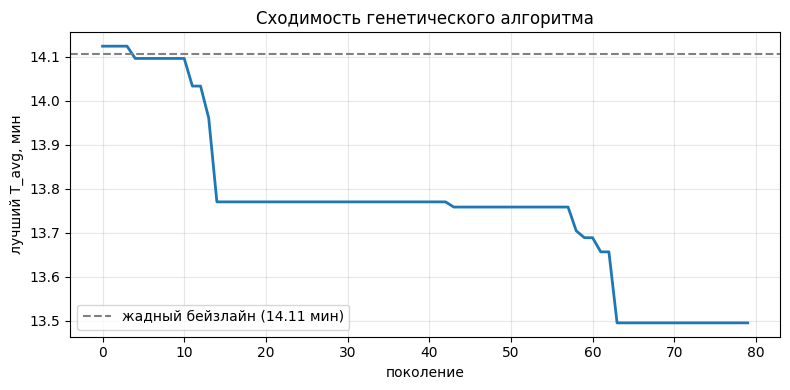

In [30]:
h = np.array(saved_hist['18 машин (факт)'])/60
plt.figure(figsize=(8,4))
plt.plot(range(len(h)), h, lw=2)
plt.axhline(gT/60, ls='--', color='gray', label=f'жадный бейзлайн ({gT/60:.2f} мин)')
plt.xlabel('поколение'); plt.ylabel('лучший T_avg, мин')
plt.title('Сходимость генетического алгоритма'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 10.2 Устойчивость: мульти-seed прогон (mean ± std)
ГА стохастичен, поэтому в отчёте корректно приводить разброс по нескольким запускам с
разными `seed`, а не одно число. (Несколько прогонов — может занять минуту.)

In [31]:
FLEET = make_fleet(8, 10)
seeds = [1, 2, 3, 4, 5]
vals = []
for sd in seeds:
    sel, T, _ = run_ga(seed=sd, verbose=False)
    vals.append(evaluate(sel)/60)
vals = np.array(vals)
print(f"T_avg по {len(seeds)} запускам: {vals.mean():.2f} ± {vals.std():.2f} мин "
      f"(мин {vals.min():.2f}, макс {vals.max():.2f})")

T_avg по 5 запускам: 13.46 ± 0.05 мин (мин 13.42, макс 13.56)


## 11. Дополнительные метрики (как в бейзлайне)
Эти метрики **не участвуют в оптимизации** (фитнес остаётся `T_avg`) — только для полноты
картины. Медиана / P90 — взвешенные по населению перцентили `T_i`; Minimax — худший подъезд
(в двух вариантах: со штрафной константой для неохваченных и только среди обслуженных).

In [32]:
FLEET = make_fleet(8, 10)
sel_base = saved_routes['18 машин (факт)']
Tavg, det = evaluate(sel_base, detail=True)
ent_time = det['ent_time']

def weighted_percentile(values, weights, q):
    order = np.argsort(values); v, w = values[order], weights[order]
    cw = np.cumsum(w); cw = cw/cw[-1]
    return float(np.interp(q/100, cw, v))

median_t = weighted_percentile(ent_time, POP, 50)
p90_t    = weighted_percentile(ent_time, POP, 90)
served = ent_time < P['unserved_penalty_s']
minimax_all    = ent_time.max()
minimax_served = ent_time[served].max() if served.any() else np.nan
print(f"Неохваченных подъездов: {(~served).sum()} "
      f"({POP[~served].sum():.0f} чел, {POP[~served].sum()/POP.sum()*100:.1f}% населения)")

metrics = pd.DataFrame([
    dict(Метрика='T_avg (среднее)',       Значение_мин=round(Tavg/60, 2)),
    dict(Метрика='Медиана',               Значение_мин=round(median_t/60, 2)),
    dict(Метрика='P90',                   Значение_мин=round(p90_t/60, 2)),
    dict(Метрика='Minimax (все)',         Значение_мин=round(minimax_all/60, 2)),
    dict(Метрика='Minimax (обслуженные)', Значение_мин=round(minimax_served/60, 2)),
])
display(metrics)

Неохваченных подъездов: 0 (0 чел, 0.0% населения)


,Метрика,Значение_мин
0,T_avg (среднее),13.50
1,Медиана,13.09
2,P90,17.40
3,Minimax (все),21.12
4,Minimax (обслуженные),21.12


## 11.1 Метрика «пешком быстрее, чем на автобусе» (как в бейзлайне)
Доля населения, для которой прямая пешая дорога до метро (5 км/ч по сети) короче поездки
на оптимизированном ГА автобусе `T_i`. Нужен файл `podyezd_dist_to_metro.csv`
(`PATHS['podyezd_dist']`) с сетевыми пешими расстояниями подъезд→метро.

In [33]:
import os
if not os.path.exists(PATHS['podyezd_dist']):
    print(f"Файл не найден: {PATHS['podyezd_dist']} — пропускаю метрику (необязательная)")
else:
    walk_df = pd.read_csv(PATHS['podyezd_dist'])
    print("Колонки файла:", walk_df.columns.tolist())
    id_col   = next((c for c in walk_df.columns
                     if c.lower() in ('entrance_id','id','fid','podyezd_id')), walk_df.columns[0])
    dist_col = next((c for c in walk_df.columns if 'dist' in c.lower()), walk_df.columns[1])
    print(f"id_col='{id_col}', dist_col='{dist_col}' (расстояние в метрах)")
    walk_df = walk_df[[id_col, dist_col]].rename(columns={id_col:'entrance_id', dist_col:'dist_m'})
    walk_df['t_walk_direct_s'] = walk_df['dist_m'] / P['walk_speed_mps']
    cmp_df = pd.DataFrame({'entrance_id': EIDS, 'population': POP, 't_bus_s': ent_time})
    cmp_df = cmp_df.merge(walk_df[['entrance_id','t_walk_direct_s']], on='entrance_id', how='left')
    n_missing = cmp_df['t_walk_direct_s'].isna().sum()
    if n_missing: print(f"Внимание: {n_missing} подъездов не нашлись в файле — исключены")
    cmp_df = cmp_df.dropna(subset=['t_walk_direct_s'])
    walk_faster = cmp_df['t_walk_direct_s'] < cmp_df['t_bus_s']
    pct_pop = cmp_df.loc[walk_faster,'population'].sum()/cmp_df['population'].sum()*100
    print(f"Подъездов, где пешком быстрее: {walk_faster.sum()} / {len(cmp_df)}")
    print(f"Доля населения, для которой пешком быстрее автобуса: {pct_pop:.1f}%")
    top = (cmp_df.loc[walk_faster]
           .assign(t_walk_min=lambda d:(d['t_walk_direct_s']/60).round(1),
                   t_bus_min =lambda d:(d['t_bus_s']/60).round(1))
           [['entrance_id','population','t_walk_min','t_bus_min']]
           .sort_values('population', ascending=False).head(10))
    display(top)

Колонки файла: ['podyezd', 'distance_to_metro_m']
id_col='podyezd', dist_col='distance_to_metro_m' (расстояние в метрах)
Внимание: 1 подъездов не нашлись в файле — исключены
Подъездов, где пешком быстрее: 0 / 620
Доля населения, для которой пешком быстрее автобуса: 0.0%


,entrance_id,population,t_walk_min,t_bus_min


## 11.2 Распределение машин по маршрутам
`evaluate(detail=True)` уже считает раздачу парка `sqrt`-правилом (`det['veh']`, `det['headway']`,
`det['cap']`, `det['flow_per_hour']`) — здесь просто выводим это в виде таблицы и диаграммы:
сколько машин каждого типа (ЛиАЗ-5292 / Volgabus-4298) выделено маршруту, какой интервал
движения это даёт, провозимость и **загрузка** (поток / провозимость, %). Загрузка > 100% —
маршрут перегружен, и в `T_avg` это уже отражено через `overflow`-штраф.

ГА (18 машин): T_avg = 13.50 мин | машин использовано: 18/18


,Маршрут,Остановок,Время_в_пути_мин,Машин,ЛиАЗ,Volgabus,Интервал_мин,Провозимость_пасс_ч,Поток_пасс_ч,Загрузка_pct
0,1,4,7.9,3,0,3,6.0,487.0,1043.0,214.0
1,2,4,6.7,3,0,3,5.1,573.0,743.0,130.0
2,3,3,7.0,4,4,0,4.0,1757.0,2115.0,120.0
3,4,6,9.1,4,4,0,5.3,1335.0,2258.0,169.0
4,5,7,10.2,4,0,4,5.9,500.0,1555.0,311.0


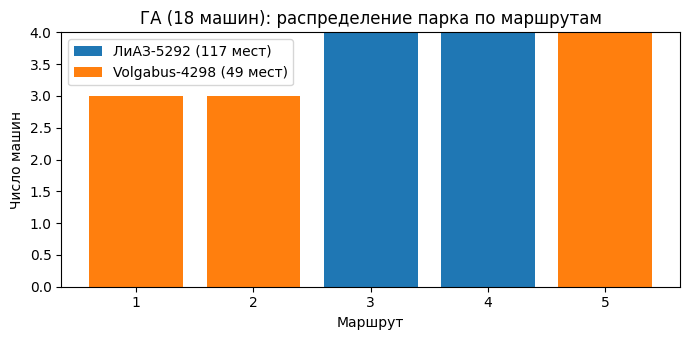

In [34]:
def fleet_table(routes, fleet, label=""):
    """Таблица: сколько машин какого типа выделено каждому маршруту,
    интервал движения, провозимость и поток. veh/headway/cap/flow_per_hour
    уже считаются внутри evaluate(detail=True) — здесь просто выводим."""
    Tavg, det = evaluate(routes, detail=True)
    rows = []
    for i, r in enumerate(routes):
        veh = det['veh'][i]
        n_liaz  = sum(1 for v in veh if v == 117)
        n_volga = sum(1 for v in veh if v == 49)
        cap, flow = det['cap'][i], det['flow_per_hour'][i]
        rows.append(dict(
            Маршрут=i+1, Остановок=len(r),
            Время_в_пути_мин=round(route_oneway_time(r)/60, 1),
            Машин=len(veh), ЛиАЗ=n_liaz, Volgabus=n_volga,
            Интервал_мин=round(det['headway'][i]/60, 1) if np.isfinite(det['headway'][i]) else None,
            Провозимость_пасс_ч=round(cap, 0),
            Поток_пасс_ч=round(flow, 0),
            Загрузка_pct=round(100*flow/cap, 0) if cap > 0 else None,
        ))
    df = pd.DataFrame(rows)
    used = sum(len(v) for v in det['veh'].values())
    print(f"{label} T_avg = {Tavg/60:.2f} мин | машин использовано: {used}/{len(fleet)}")
    display(df)

    # столбчатая диаграмма: состав парка по маршрутам
    fig, ax = plt.subplots(figsize=(7, 3.5))
    x = df['Маршрут']
    ax.bar(x, df['ЛиАЗ'], label='ЛиАЗ-5292 (117 мест)', color='tab:blue')
    ax.bar(x, df['Volgabus'], bottom=df['ЛиАЗ'], label='Volgabus-4298 (49 мест)', color='tab:orange')
    ax.set_xlabel('Маршрут'); ax.set_ylabel('Число машин')
    ax.set_title(f'{label} распределение парка по маршрутам')
    ax.legend(); ax.set_xticks(x)
    plt.tight_layout(); plt.show()
    return df

FLEET = make_fleet(8, 10)
_ = fleet_table(saved_routes['18 машин (факт)'], FLEET, "ГА (18 машин):")

## 12. Экспорт маршрутов ГА в GeoPackage (для QGIS)
Строим геометрию каждого выбранного маршрута вдоль графа и сохраняем слои `routes` и `served_stops`.

In [35]:
def route_polyline(route):
    node_seq = [board_nodes[s] for s in route] + [metro_nodes[0]]
    coords = []
    for a, b in zip(node_seq[:-1], node_seq[1:]):
        try: path = nx.shortest_path(G, a, b, weight='time')
        except nx.NetworkXNoPath: continue
        coords += path if not coords else path[1:]
    return LineString(coords) if len(coords) >= 2 else None

sel = saved_routes['18 машин (факт)']
rows = [dict(route_id=i+1, n_stops=len(r), geometry=route_polyline(r))
        for i, r in enumerate(sel) if route_polyline(r)]
routes_gdf = gpd.GeoDataFrame(rows, crs=CRS)
routes_gdf.to_file(PATHS['out'], layer='routes', driver='GPKG')

served_idx = sorted(set(s for r in sel for s in r))
board.iloc[served_idx].to_file(PATHS['out'], layer='served_stops', driver='GPKG')
print("Сохранено", PATHS["out"], "—", len(routes_gdf), "маршрутов,", len(served_idx), "остановок")

Сохранено C:\Users\georg\NIS\Curse_work_2026\ga_routes_v2.gpkg — 5 маршрутов, 21 остановок


## 13. Визуализация в Python (matplotlib)

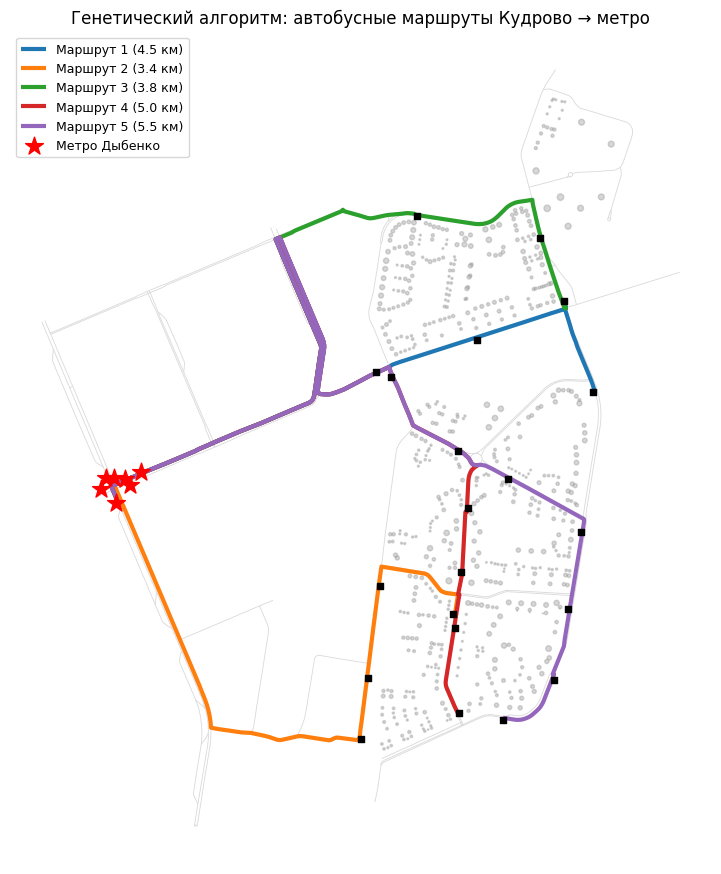

In [36]:
roads = gpd.read_file(PATHS['roads'], layer='doroga_for_busiki').to_crs(CRS)
fig, ax = plt.subplots(figsize=(11, 9))
roads.plot(ax=ax, color='0.85', lw=0.6, zorder=1)
ent.plot(ax=ax, color='0.6', markersize=ent['population']/30, alpha=0.4, zorder=2)
cmap = plt.cm.tab10
for i, (_, r) in enumerate(routes_gdf.iterrows()):
    gpd.GeoSeries([r.geometry], crs=CRS).plot(ax=ax, color=cmap(i % 10), lw=3, zorder=4,
        label=f"Маршрут {r['route_id']} ({r.geometry.length/1000:.1f} км)")
board.iloc[served_idx].plot(ax=ax, color='black', markersize=22, marker='s', zorder=5)
metro.plot(ax=ax, color='red', markersize=180, marker='*', zorder=6, label='Метро Дыбенко')
ax.legend(loc='upper left', fontsize=9)
ax.set_title('Генетический алгоритм: автобусные маршруты Кудрово → метро')
ax.set_axis_off(); plt.tight_layout(); plt.show()

## 14. Визуализация в QGIS
1. **Layer → Add Layer → Add Vector Layer** → `ga_routes_v2.gpkg` (слои `routes` и `served_stops`).
2. Разноцветные маршруты: ПКМ по `routes` → **Properties → Symbology → Categorized** →
   Value `route_id` → **Classify**.
3. Подложка: **Plugins → QuickMapServices → OSM Standard**.
4. Сравнение со старой сетью: добавьте слой существующих маршрутов из `avtobus_marshruty.gpkg`
   полупрозрачным поверх, чтобы сопоставить трассы.

## Что показывает эксперимент (для выводов курсовой)
- **Генетический алгоритм бьёт жадный бейзлайн** на идентичной формулировке (тот же пул,
  та же фитнес-функция, тот же парк) — выигрыш исключительно за счёт более широкого поиска,
  уходящего из локального оптимума, где застревает жадность.
- ГА также заметно превосходит существующую сеть по `T_avg`.
- Результат воспроизводим (фиксированный `seed`), а его устойчивость подтверждена
  мульти-seed прогоном (mean ± std).
- Это — метаэвристический бейзлайн ML-части. Следующий шаг работы (GNN + Deep RL) должен
  побить уже его: в отличие от ГА, обучаемая политика переносится на новые конфигурации без
  полного перезапуска поиска.
